# Lab 4

Authors: Khanh Do, Nicky Moreno Gonzalez

### Imports

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import QuantileTransformer
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import ValidationCurveDisplay
from sklearn.model_selection import GridSearchCV
from scipy.stats import poisson, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, MaxAbsScaler, MinMaxScaler
from sklearn.metrics import accuracy_score

# # KNN functions may produce FutureWarnings; the command below suppresses them.
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning) 

from sklearn.model_selection import train_test_split
ic_homes = pd.read_csv("https://remiller1450.github.io/data/IowaCityHomeSales.csv")
ic_train, ic_test = train_test_split(ic_homes, test_size=0.2, random_state=7)

## Question 1

### Part A

In [21]:
pipeline_1a = Pipeline([
    ('transformer',  QuantileTransformer(n_quantiles = len(ic_train), output_distribution = "uniform")),
    ('model', KNeighborsRegressor(n_neighbors = 5, weights = "distance"))
])

## Fit to training data (using only area.lot and area.bsmt as predictive features)
my_variables = ['area.lot','area.bsmt']
ic_train_X = ic_train[my_variables]
ic_train_y = ic_train['sale.amount']
fitted_pipe = pipeline_1a.fit(X = ic_train_X, y = ic_train_y)

## Predict on test data
from sklearn.metrics import root_mean_squared_error
ic_test_X = ic_test[my_variables]
ic_test_y = ic_test['sale.amount']
root_mean_squared_error(ic_test_y, fitted_pipe.predict(ic_test_X))

70235.25070962134

### Part B

In [22]:
ks = [4,8,12,16,20]

for k in ks:
    pipeline_2a = pipeline_1a.set_params(model__n_neighbors = k)
    fitted_pipe = pipeline_1a.fit(X = ic_train_X, y = ic_train_y)
    print(f"When k = {k}, RMSE = {root_mean_squared_error(ic_test_y, fitted_pipe.predict(ic_test_X))}")

When k = 4, RMSE = 72135.47150212026
When k = 8, RMSE = 68960.6995616218
When k = 12, RMSE = 67739.53450313523
When k = 16, RMSE = 67709.27030684116
When k = 20, RMSE = 67819.0437932345


## Question 2

### Part A

In [23]:
pipeline_2a = Pipeline([
    ('pca',  PCA()),
    ('model', DecisionTreeRegressor())
])
fitted_pipe = pipeline_2a.fit(X = ic_train_X, y = ic_train_y)

### Part B

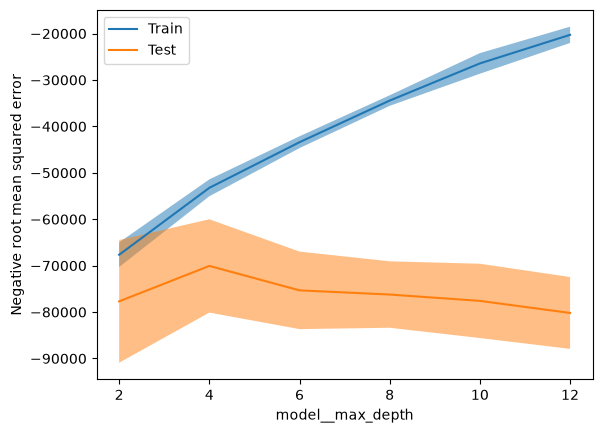

In [24]:
depth = range(2, 12 + 1, 2)
ValidationCurveDisplay.from_estimator(pipeline_2a, ic_train_X, ic_train_y, 
                                      param_name="model__max_depth",  
                                      scoring='neg_root_mean_squared_error',
                                      cv = 5,
                                      param_range=[i for i in depth])
plt.show()

### Part C

In [25]:
params = {
    'pca': [PCA(n_components=0.8), 'passthrough'],
    'model__max_depth': [4, 6, 8],
    'model__min_samples_split': [100, 2] 
}
params_to_print = [
    'rank_test_score',
    'param_pca',
    'param_model__max_depth',
    'param_model__min_samples_split',
    'mean_test_score'
]
grid_results = GridSearchCV(pipeline_2a, params, cv=10, scoring='neg_root_mean_squared_error').fit(ic_train_X, ic_train_y)
pd.DataFrame(grid_results.cv_results_).sort_values(by='rank_test_score')[params_to_print].head(5)

,rank_test_score,param_pca,param_model__max_depth,param_model__min_samples_split,mean_test_score
3,1,passthrough,4,2,-69312.618401
8,2,PCA(n_components=0.8),8,100,-70649.448814
4,3,PCA(n_components=0.8),6,100,-70656.223949
9,4,passthrough,8,100,-70837.198724
5,5,passthrough,6,100,-70935.418149


### Part D

In [26]:
root_mean_squared_error(
    ic_test_y,
    grid_results.best_estimator_.predict(ic_test_X)
)

70890.3009833577

## Question 3

In [27]:
pipeline_3 = Pipeline([
    ('pca',  PCA()),
    ('model', DecisionTreeRegressor())
])
params = {
    'model__max_depth': poisson(4),
    'model__min_samples_split': uniform(0, 0.8)
    }
params_to_print = [
    'rank_test_score',
    'param_model__max_depth',
    'param_model__min_samples_split',
    'mean_test_score'
]
results = RandomizedSearchCV(
    pipeline_3,
    params,
    n_iter=25,
    scoring='neg_root_mean_squared_error',
    random_state=0
).fit(ic_train_X, ic_train_y)
pd.DataFrame(results.cv_results_).sort_values(by='rank_test_score')[params_to_print].head(5)

,rank_test_score,param_model__max_depth,param_model__min_samples_split,mean_test_score
4,1,5,0.015032,-70546.955441
5,2,7,0.048180,-71042.303454
1,3,6,0.069703,-71630.304658
7,4,4,0.167101,-72349.616381
12,5,4,0.226246,-72632.533438


## Question 4

In [28]:
# Try adding another dictionary to our list
my_params = [
    {"model": [DecisionTreeRegressor()],
        "model__max_depth": [2, 4, 6]},
    {"scaler": [MinMaxScaler(), RobustScaler()],
        "model": [KNeighborsRegressor()],
        "model__n_neighbors": [15, 30]},
    {"scaler": [MinMaxScaler(), RobustScaler()]}
]
my_pipeline = Pipeline([
    ('scaler', 'passthrough'),
    ('model', KNeighborsRegressor())
])

grid_results = GridSearchCV(my_pipeline, my_params, cv=5, scoring='neg_root_mean_squared_error').fit(ic_train_X, ic_train_y)
pd.DataFrame(grid_results.cv_results_).sort_values(by='rank_test_score').head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model,param_model__max_depth,param_model__n_neighbors,param_scaler,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
4,0.004992,0.000449,0.003395,0.000533,KNeighborsRegressor(),NaN,15.0,RobustScaler(),"{'model': KNeighborsRegressor(), 'model__n_nei...",-59089.008922,-70545.825054,-84831.547459,-48290.427286,-79154.938407,-68382.349425,13276.723459,1
7,0.003009,0.000131,0.002245,0.000236,NaN,NaN,NaN,MinMaxScaler(),{'scaler': MinMaxScaler()},-69453.423400,-67449.501030,-76770.123386,-51380.091640,-78933.433815,-68797.314654,9715.074148,2
6,0.004147,0.000336,0.002555,0.000103,KNeighborsRegressor(),NaN,30.0,RobustScaler(),"{'model': KNeighborsRegressor(), 'model__n_nei...",-56885.663581,-72302.577787,-84369.836506,-49417.853972,-81964.441927,-68988.074755,13750.872901,3
3,0.003929,0.000389,0.003132,0.000308,KNeighborsRegressor(),NaN,15.0,MinMaxScaler(),"{'model': KNeighborsRegressor(), 'model__n_nei...",-60270.932974,-72917.596289,-81026.560904,-50567.508939,-82445.486736,-69445.617168,12294.123035,4
1,0.002630,0.000236,0.001792,0.000230,DecisionTreeRegressor(),4.0,NaN,NaN,"{'model': DecisionTreeRegressor(), 'model__max...",-60868.253606,-73236.644144,-79723.617926,-57738.032191,-78215.168794,-69956.343332,9013.864060,5


**Comment:** This does not work as intended (applying the scaling to both models above the entry) because each dictionary is a separate space of parameters searching, so doing this would test the scalers while leaving the pipeline's existing model unchanged.

The way to do this would be:

In [29]:
my_params = [
    {"scaler": [MinMaxScaler(), RobustScaler()],
        "model": [DecisionTreeRegressor()],
        "model__max_depth": [2, 4, 6]},
    {"scaler": [MinMaxScaler(), RobustScaler()],
        "model": [KNeighborsRegressor()],
        "model__n_neighbors": [15, 30]}
]
my_pipeline = Pipeline([
    ('scaler', 'passthrough'),
    ('model', KNeighborsRegressor())
])

grid_results = GridSearchCV(my_pipeline, my_params, cv=5, scoring='neg_root_mean_squared_error').fit(ic_train_X, ic_train_y)
pd.DataFrame(grid_results.cv_results_).sort_values(by='rank_test_score').head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model,param_model__max_depth,param_scaler,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
7,0.005223,0.000587,0.002916,0.000194,KNeighborsRegressor(),NaN,RobustScaler(),15.0,"{'model': KNeighborsRegressor(), 'model__n_nei...",-59089.008922,-70545.825054,-84831.547459,-48290.427286,-79154.938407,-68382.349425,13276.723459,1
9,0.005057,0.000681,0.003160,0.000452,KNeighborsRegressor(),NaN,RobustScaler(),30.0,"{'model': KNeighborsRegressor(), 'model__n_nei...",-56885.663581,-72302.577787,-84369.836506,-49417.853972,-81964.441927,-68988.074755,13750.872901,2
6,0.005074,0.000467,0.003404,0.000431,KNeighborsRegressor(),NaN,MinMaxScaler(),15.0,"{'model': KNeighborsRegressor(), 'model__n_nei...",-60270.932974,-72917.596289,-81026.560904,-50567.508939,-82445.486736,-69445.617168,12294.123035,3
3,0.005193,0.000469,0.002010,0.000210,DecisionTreeRegressor(),4.0,RobustScaler(),NaN,"{'model': DecisionTreeRegressor(), 'model__max...",-60868.253606,-73236.644144,-79723.617926,-57738.032191,-78215.168794,-69956.343332,9013.864060,4
2,0.003772,0.000331,0.001816,0.000143,DecisionTreeRegressor(),4.0,MinMaxScaler(),NaN,"{'model': DecisionTreeRegressor(), 'model__max...",-60868.253606,-73236.644144,-79723.617926,-57738.032191,-78215.168794,-69956.343332,9013.864060,4


## Question 5

In [30]:
## Imports
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, PowerTransformer

## Set up data w/ mixed feature types 
my_variables = ['area.lot', 'area.living', 'style']
ic_train_X = ic_train[my_variables]
ic_train_y = ic_train['sale.amount']

## Get names of numeric and categorical columns
num_cols = ic_train_X.select_dtypes(exclude=['object']).columns.tolist()
cat_cols = ic_train_X.select_dtypes(include=['object']).columns.tolist()

## Make a separate pipeline for numeric vs. cat vars
num_transformer = Pipeline([('transformer',  PowerTransformer(method = 'yeo-johnson')),
                            ("scaler", StandardScaler())])
cat_transformer = Pipeline([("encoder", OneHotEncoder(sparse_output=False, handle_unknown='ignore'))])

## Put these pipelines together using ColumnTransformer()
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

## Create the final pipeline
final_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor())
])


/tmp/ipykernel_126302/4113719856.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = ic_train_X.select_dtypes(include=['object']).columns.tolist()


In [31]:
my_params = {
    'preprocessor__num__scaler': [
        StandardScaler(),
        RobustScaler()
    ],

    'model__n_neighbors': [10, 20]
}

grid_results = GridSearchCV(final_pipe, my_params, cv=5, scoring='neg_root_mean_squared_error').fit(ic_train_X, ic_train_y)
# pd.DataFrame(grid_results.cv_results_).sort_values(by='rank_test_score').head(5)
grid_results.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['area.lot','area.living','style']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the 

## Question 6

### Part A

In [32]:
### Read flattened, processed data
mnist = pd.read_csv("https://remiller1450.github.io/data/mnist_small.csv")

### Separate the target variable (label column)
label = mnist['label']
mnist = mnist.drop(['label'], axis=1)

### Convert to numpy array and reshape to 28 by 28
mnist_unflattened = mnist.to_numpy()
mnist_unflattened = mnist_unflattened.reshape(6000,28,28)

# Split
mnist_train, mnist_test, label_train, label_test = train_test_split(mnist,label, test_size=0.1,random_state=10)

### Part B

In [33]:
pipeline_6b = Pipeline([
    ('scaler', 'passthrough'),
    ('pca', 'passthrough'),
    ('model', KNeighborsClassifier())
])

### Part C

In [34]:
params = [
    # decision tree
    {
        'model': [DecisionTreeClassifier()],
        'model__max_depth': [2, 6, 10],
        'scaler': [
            StandardScaler(),
            RobustScaler(),
            'passthrough'
        ],

        'pca': [
            PCA(n_components=0.7),
            PCA(n_components=0.8),
            PCA(n_components=0.9),
            'passthrough'
        ],
    },
    
    # knn
    {
        'model': [KNeighborsClassifier()],
        'model__n_neighbors': [2, 4, 8],
        'scaler': [
            StandardScaler(),
            RobustScaler(),
            'passthrough'
        ],
        'pca': [
            PCA(n_components=0.7),
            PCA(n_components=0.8),
            PCA(n_components=0.9),
            'passthrough'
        ],
    }
]
grid_results = GridSearchCV(
    pipeline_6b,
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,  # run parallel otherwise it will take forever
).fit(mnist_train, label_train)

### Part D

In [35]:
params_to_print = [
    'rank_test_score',
    'param_scaler',
    'param_pca',
    'param_model',
    'param_model__n_neighbors',
    'param_model__max_depth',
    'mean_test_score'
]
pd.DataFrame(grid_results.cv_results_).sort_values(by='rank_test_score')[params_to_print].head(3)

,rank_test_score,param_scaler,param_pca,param_model,param_model__n_neighbors,param_model__max_depth,mean_test_score
53,1,passthrough,PCA(n_components=0.8),KNeighborsClassifier(),4.0,NaN,0.944444
50,2,passthrough,PCA(n_components=0.7),KNeighborsClassifier(),4.0,NaN,0.942778
65,3,passthrough,PCA(n_components=0.8),KNeighborsClassifier(),8.0,NaN,0.942222


### Part E

**Evaluation:** My top 3 configuartions identified in Part D on the test set were all KNN with no scaling. The top 2 used 4 neighbors and the configuration at top 3 used 8 neighbors. The best one had a PCA retaining 80% of the variance and achieved a mean score of about 94%. What surprises me the most is that not scaling performed best and retaining 80% variance performed better than retaining 90% variance during PCA reduction. KNN with neighbors of 4 performing best makes sense to me because 2 is too low and 8 might be too high.

In [36]:
y_pred = grid_results.best_estimator_.predict(mnist_test)
accuracy_score(label_test, y_pred)

0.9416666666666667

On the test set, the best configuration achieved accuracy score of 94%.

In [37]:
grid_results.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",0.8
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimensi

### Part F

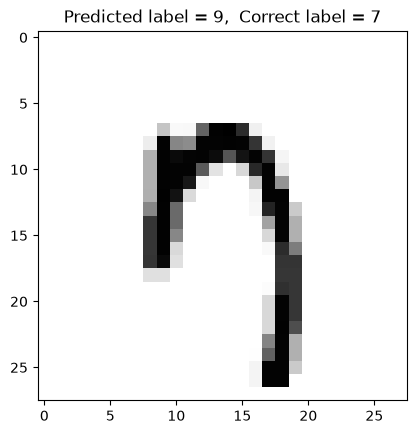

In [38]:
# Find the first digit in the test set that was incorrectly classified
first_digit = (np.where(y_pred != label_test.to_numpy())[0])[0]
image = mnist_test.iloc[first_digit].to_numpy().reshape(28, 28)
correct_label = label_test.iloc[first_digit]
pred_label = y_pred[first_digit]
# Display it as an image with the predicted label and correct label as title text
plt.imshow(image, cmap='Greys')
plt.title(f"Predicted label = {pred_label},  Correct label = {correct_label}")
plt.show()